# 📊 Decoding the Data & Tech Profession in Indonesia (2022)
### *Top Job Positions, Industry Demands, Gender Distribution, and Educational Pathways*

> **Tujuan:** Untuk memperoleh wawasan mengenai Careers & Job Outlook di bidang Data & Tech di Indonesia pada tahun 2022

---

## Rumusan Masalah
1. What are the **top Data & Tech job positions** in Indonesia Market?
2. What **industries** are hiring Data & Tech professionals and what roles do they seek?
3. How is the **gender distribution** of Data & Tech Jobs in Indonesia?
4. What **education** do Data & Tech professionals need based on Indonesia country?

## Tujuan Proyek
Menganalisis dan mengungkapkan panorama pekerjaan di bidang Data & Teknologi di Indonesia pada tahun 2022 dengan fokus pada empat aspek utama:

1. **Identifikasi Posisi Pekerjaan Unggulan** — Mengidentifikasi posisi pekerjaan terkemuka di industri Data & Tech Indonesia, mencakup Data Scientist, ML Engineer, Analyst, Manager, Teacher, dan lainnya.
2. **Tren Industri** — Menelusuri industri yang paling aktif merekrut profesional Data & Tech.
3. **Analisis Distribusi Gender** — Menggali distribusi pekerjaan Data & Tech berdasarkan gender.
4. **Persyaratan Pendidikan** — Menyelidiki tingkat pendidikan yang paling umum di kalangan profesional Data & Tech Indonesia.


In [1]:
# ============================================================
# Install dependencies yang dibutuhkan
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["jinja2", "plotly", "pandas", "numpy", "matplotlib", "nbformat", "kaleido"]

for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
        print(f" {pkg} sudah terinstall")
    except ImportError:
        print(f" Menginstall {pkg}...")
        install(pkg)
        print(f" {pkg} berhasil diinstall")


 jinja2 sudah terinstall
 plotly sudah terinstall
 pandas sudah terinstall
 numpy sudah terinstall
 matplotlib sudah terinstall
 nbformat sudah terinstall
 Menginstall kaleido...
 kaleido berhasil diinstall


## 1. Import Libraries

In [2]:
# ============================================================
# Import semua library yang dibutuhkan
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from collections import Counter

# Plotly untuk visualisasi interaktif
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.express as px

# Konfigurasi renderer agar plot tersimpan sebagai PNG di output cell
# (diperlukan agar visualisasi terlihat di GitHub)
import plotly.io as pio
pio.renderers.default = 'png'

# Matplotlib untuk visualisasi statis
import matplotlib as mpl
import matplotlib.pyplot as plt

# IPython display utilities
try:
    from IPython.display import display, HTML 
except ImportError:
    from IPython.core.display import display, HTML 

## 2. Load Dataset

In [3]:
# ============================================================
# Load dataset langsung dari GitHub (tidak perlu git clone)
# ============================================================

df = pd.read_csv('data/kaggle_survey_2022_responses.csv')

# Baris pertama berisi judul pertanyaan
questions_titles = df[0:1].copy()

# Hapus baris pertama dari data utama
df = df[1:].reset_index(drop=True)

print(f"   Jumlah responden total : {df.shape[0]:,}")
print(f"   Jumlah kolom           : {df.shape[1]:,}")

   Jumlah responden total : 23,997
   Jumlah kolom           : 296


## 3. Helper Functions

In [4]:
# ============================================================
# Helper Functions untuk Visualisasi
# ============================================================

def create_scatter_plot(
    x_axis_values,
    y_axis_values,
    hover_template,
    marker_color,
    marker_size,
    title,
    subtitle,
    subtitle_explain,
    customdata=None,
):
    """Membuat scatter plot interaktif dengan Plotly."""
    trace = go.Scatter(
        x=x_axis_values,
        y=y_axis_values,
        mode='markers',
        hovertemplate=hover_template,
        customdata=customdata,   
        marker=dict(
            color=marker_color,
            size=marker_size,
            showscale=True,
            colorbar=dict(title="Percent"),
            opacity=0.75,
            colorscale='Plasma',
        )
    )

    layout = go.Layout(
        width=950,
        height=970,
        plot_bgcolor="#f8f8f8",
        paper_bgcolor="#f8f8f8",
        showlegend=False,
        title={
            'text': (
                f"<span style='font-size:28px; font-family:Georgia'><b>{title}</b></span>"
                f"<br><br><sup>{subtitle}</sup><br><sup>{subtitle_explain}</sup>"
            ),
            'x': 0.5,
            'xanchor': 'center'
        },
        font={"color": '#333333'},
        margin=dict(t=180),
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.update_xaxes(
        showline=False, gridcolor='#c9c4c3',
        tickfont=dict(size=13, family='Verdana', color='#333333'),
        title="", showgrid=False, tickangle=325
    )
    fig.update_yaxes(
        showline=False, gridcolor='#e0e0e0',
        tickfont=dict(size=13, family='Verdana', color='#555555'),
        title="", showgrid=True
    )
    fig.show(renderer='png')


def get_bar_plot_trace(x_values, y_values, display_text, top_n, rest_n, hovertext, orientation="h"):
    """Menghasilkan trace untuk bar plot."""
    trace = go.Bar(
        y=y_values,
        x=x_values,
        name="",
        orientation=orientation,
        marker=dict(
            color=["#ffc107"] * rest_n + ["#e65100"] * top_n,
        ),
        text=display_text,
        texttemplate="<b style='color: #fff'>%{text}%</b>",
        textposition=["outside"] * rest_n + ["inside"] * top_n,
        hovertext=hovertext
    )
    return trace


def create_single_bar_plot(
    x_values, y_values, display_text, top_n, rest_n,
    hovertext, title, subtitle="", orientation="h"
):
    """Membuat single bar plot dengan Plotly."""
    trace = get_bar_plot_trace(
        x_values, y_values, display_text, top_n, rest_n, hovertext, orientation
    )
    large_title_format = (
        f"<span style='font-size:28px; font-family:Georgia'><b>{title}</b></span>"
    )
    layout = go.Layout(
        title=dict(
            text=large_title_format,
            x=0.5,  
            xanchor="center", 
            ),
        font=dict(color='#4d4d4d'),
        margin=dict(t=120),
        yaxis={'categoryorder': 'array', 'categoryarray': y_values},
        xaxis=dict(
            side="top", zerolinecolor="#4d4d4d", zerolinewidth=0.5,
            gridcolor="#e7e7e7", tickformat=",.1%"
        ),
        width=850,
        height=700,
        plot_bgcolor="#f9f9f9",
    )
    fig = go.Figure(data=trace, layout=layout)
    fig.show(renderer='png')


def extract_the_number_of_responses(question_title: str, row: pd.Series, columns_list: list) -> int:
    """Menghitung jumlah responden yang memilih jawaban tertentu pada multiple-choice question."""
    return sum(
        1 for col in columns_list
        if col.startswith(question_title) and not pd.isnull(row[col])
    )


def wrap_df_text(df):
    """Menampilkan DataFrame dengan gradient warna (butuh jinja2)."""
    try:
        import jinja2  
        styled = (
            df.style
            .background_gradient(axis=0, cmap='YlOrBr', subset=["Average number of selected choices"])
            .set_properties(**{'text-align': 'left'})
        )
        return display(HTML(styled.to_html().replace("\\n", "<br>")))
    except ImportError:
        # Fallback: tampilkan tabel biasa jika jinja2 belum terinstall
        print("⚠️  jinja2 tidak ditemukan — menampilkan tabel tanpa styling.")
        print("   Jalankan: pip install jinja2")
        return display(df)

## 🇮🇩 4. Filter Data Indonesia

In [5]:
# ============================================================
# Filter hanya responden yang bekerja di Indonesia
# Kriteria:
#   - Q5 == "No"  → bukan student
#   - Q24 != null → menjawab industri tempat bekerja
#   - Q23 != "Currently not employed"
#   - Q4 == "Indonesia"
# ============================================================
new_df = df[
    (df["Q5"] == "No") &
    (df["Q24"].notnull()) &
    (df["Q23"] != "Currently not employed") &
    (df["Q4"] == "Indonesia")
]

cols_needed = [
    'Q2', 'Q3', 'Q4', 'Q5', 'Q8', 'Q23', 'Q24',
    'Q28_1', 'Q28_2', 'Q28_3', 'Q28_4', 'Q28_5', 'Q28_6', 'Q28_7', 'Q28_8'
]
indonesia_df = new_df[cols_needed].copy().reset_index(drop=True)

print(f"   Jumlah profesional Data & Tech di Indonesia : {indonesia_df.shape[0]}")

   Jumlah profesional Data & Tech di Indonesia : 111


## 📊 5. Eksplorasi & Visualisasi Data

### 5.1 Key Figures

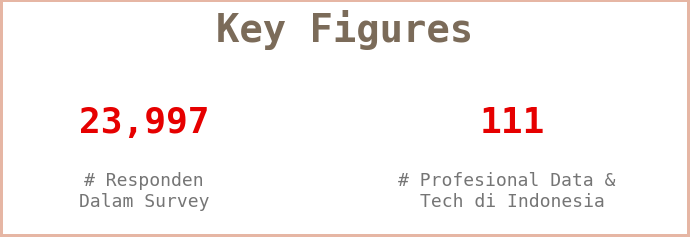

In [6]:
# ============================================================
# Visualisasi Key Figures
# ============================================================
mpl.rcParams.update(mpl.rcParamsDefault)

fig1, ax1 = plt.subplots(figsize=(7, 2.5), facecolor='white')
font = 'monospace'

ax1.text(0.5, 0.88, "Key Figures", color='#7b6b59',
         fontsize=28, fontweight='bold', fontfamily=font, ha='center',
         transform=ax1.transAxes)

ax1.text(0.2, 0.45, f"{df.shape[0]:,}", color='#e60000',
         fontsize=26, fontweight='bold', fontfamily=font, ha='center',
         transform=ax1.transAxes)
ax1.text(0.2, 0.10, "# Responden\nDalam Survey", color='#757575',
         fontsize=13, fontfamily=font, ha='center', transform=ax1.transAxes)

ax1.text(0.75, 0.45, str(indonesia_df.shape[0]), color='#e60000',
         fontsize=26, fontweight='bold', fontfamily=font, ha='center',
         transform=ax1.transAxes)
ax1.text(0.75, 0.10, "# Profesional Data & \nTech di Indonesia", color='#757575',
         fontsize=13, fontfamily=font, ha='center', transform=ax1.transAxes)

ax1.axis('off')
for spine in ax1.spines.values():
    spine.set_visible(False)

fig1.patch.set_linewidth(3)
fig1.patch.set_edgecolor('#E6b6a4')
fig1.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


### 5.2 Analisis Rata-Rata Pilihan Multiple-Choice

In [7]:
# ============================================================
# Hitung rata-rata jumlah pilihan pada multiple-choice questions
# ============================================================
multiple_choice_questions = {}
seen_columns = []

for col in indonesia_df.columns:
    question = col.split("_")[0]
    if question in seen_columns:
        multiple_choice_questions[question] = multiple_choice_questions.get(question, 1) + 1
    else:
        seen_columns.append(question)

for col in multiple_choice_questions:
    indonesia_df[f"{col}_number_of_responses"] = indonesia_df.apply(
        lambda x: extract_the_number_of_responses(col, x, df.columns), axis=1
    )

outlier_analysis = []
for col in multiple_choice_questions:
    mean_responses = round(indonesia_df[f"{col}_number_of_responses"].mean())
    outlier_analysis.append([col, multiple_choice_questions[col], mean_responses])

average_responses = pd.DataFrame(
    outlier_analysis,
    columns=["Question", "Nbr of available Choices", "Average number of selected choices"]
)

q1_keys = [f"{col}_1" for col in multiple_choice_questions if f"{col}_1" in questions_titles.columns]
if q1_keys:
    average_responses["Question Title"] = questions_titles[q1_keys].loc[0].to_list()
    average_responses["Question Title"] = average_responses["Question Title"].apply(
        lambda x: x.split("(Select")[0].strip()
    )

# Hapus kolom sementara
indonesia_df.drop(
    [f"{col}_number_of_responses" for col in multiple_choice_questions],
    axis=1, inplace=True
)

average_responses["Question Title"] = average_responses["Question Title"].str.wrap(80)
average_responses = average_responses[
    ["Question", "Question Title", "Nbr of available Choices", "Average number of selected choices"]
]
wrap_df_text(average_responses)


,Question,Question Title,Nbr of available Choices,Average number of selected choices
0,Q28,Select any activities that make up an important part of your role at work:,8,2


### 5.3 ❓ Q1: Top Data & Tech Job Positions in Indonesia


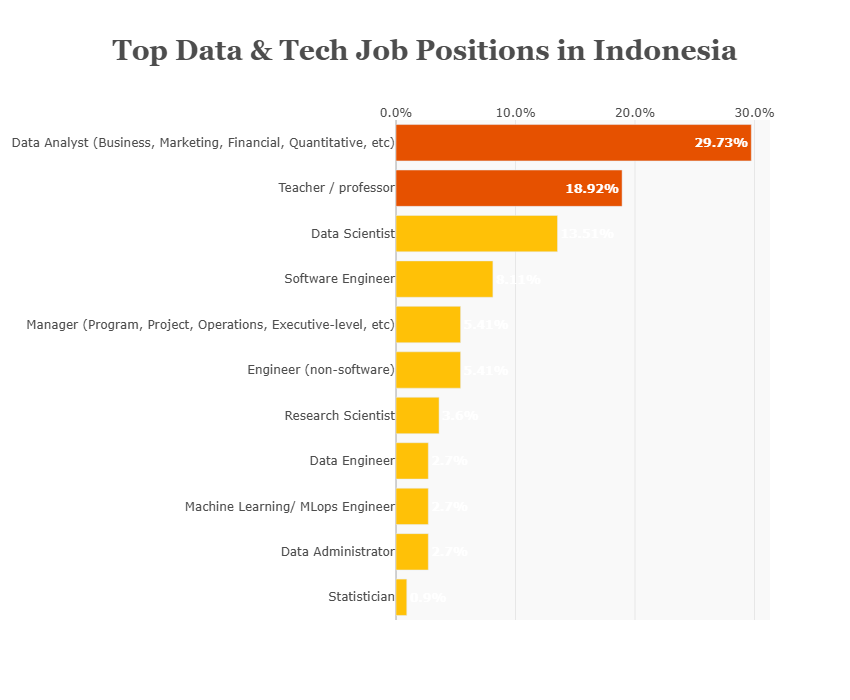

In [8]:
# ============================================================
# Visualisasi: Top Data & Tech Job Positions in Indonesia
# ============================================================
data_science_roles = (
    indonesia_df.groupby("Q23")
    .agg(counts=("Q2", "count"))
    .reset_index()
)
data_science_roles["relative_percent"] = data_science_roles["counts"] / indonesia_df.shape[0]
data_science_roles = data_science_roles[
    ~data_science_roles["Q23"].isin(["None", "Other"])
].sort_values("relative_percent", ascending=True)

create_single_bar_plot(
    x_values=data_science_roles["relative_percent"].tolist(),
    y_values=data_science_roles["Q23"].tolist(),
    display_text=np.round(data_science_roles["relative_percent"] * 100, decimals=2),
    top_n=2,
    rest_n=len(data_science_roles) - 2,
    hovertext=data_science_roles["counts"].tolist(),
    title="Top Data & Tech Job Positions in Indonesia",
    orientation="h"
)


### 5.4 ❓ Q2: Industries Hiring Data & Tech Professionals in Indonesia


In [9]:
# ============================================================
# Distribusi industri yang merekrut AI Specialist
# ============================================================
industry_totals = indonesia_df["Q24"].value_counts().to_dict()
print("Top 10 Industri:")
for ind, count in list(industry_totals.items())[:10]:
    print(f"  {ind:<50} → {count} responden")


Top 10 Industri:
  Academics/Education                                → 35 responden
  Computers/Technology                               → 19 responden
  Accounting/Finance                                 → 11 responden
  Manufacturing/Fabrication                          → 10 responden
  Retail/Sales                                       → 8 responden
  Government/Public Service                          → 5 responden
  Marketing/CRM                                      → 5 responden
  Medical/Pharmaceutical                             → 4 responden
  Other                                              → 4 responden
  Energy/Mining                                      → 3 responden


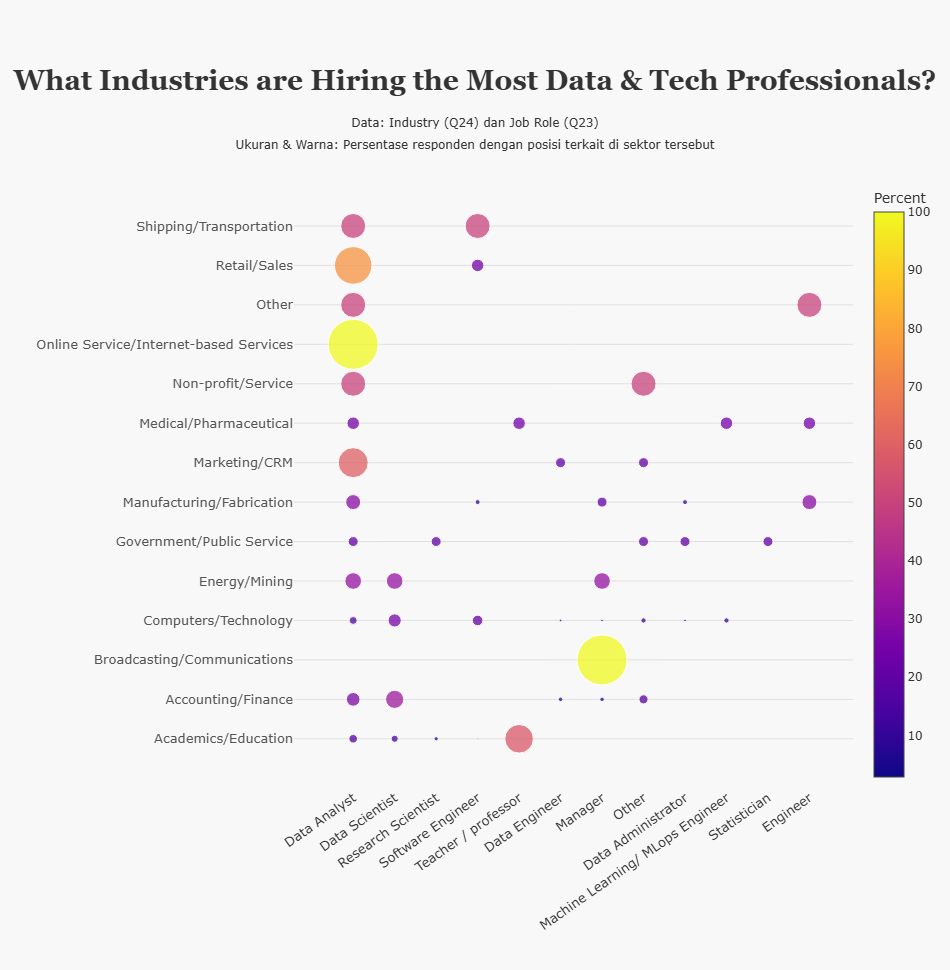

In [10]:
# ============================================================
# Scatter plot: Industri vs Role AI
# ============================================================
roles_df = (
    indonesia_df.groupby(["Q24", "Q23"])
    .agg(counts=("Q2", "count"))
    .reset_index()
)
roles_df["relative_percent"] = roles_df.apply(
    lambda x: x["counts"] / industry_totals[x["Q24"]], axis=1
)

create_scatter_plot(
    x_axis_values=roles_df["Q23"].apply(lambda x: x.split("(")[0].strip()),
    y_axis_values=roles_df["Q24"],
    hover_template=(
        "Role: %{x}<br>"
        "Industry: %{y}<br>"
        "Percentage: %{customdata:.1f}%" 
        "<extra></extra>"
    ),
    marker_color=roles_df["relative_percent"] * 100,
    marker_size=roles_df["relative_percent"] * 50,
    customdata=roles_df["relative_percent"] * 100,  
    title="What Industries are Hiring the Most Data & Tech Professionals?",
    subtitle="Data: Industry (Q24) dan Job Role (Q23)",
    subtitle_explain=(
        "Ukuran & Warna: Persentase responden dengan posisi terkait di sektor tersebut"
    )
)


#### Work Activities & Role Responsibilities


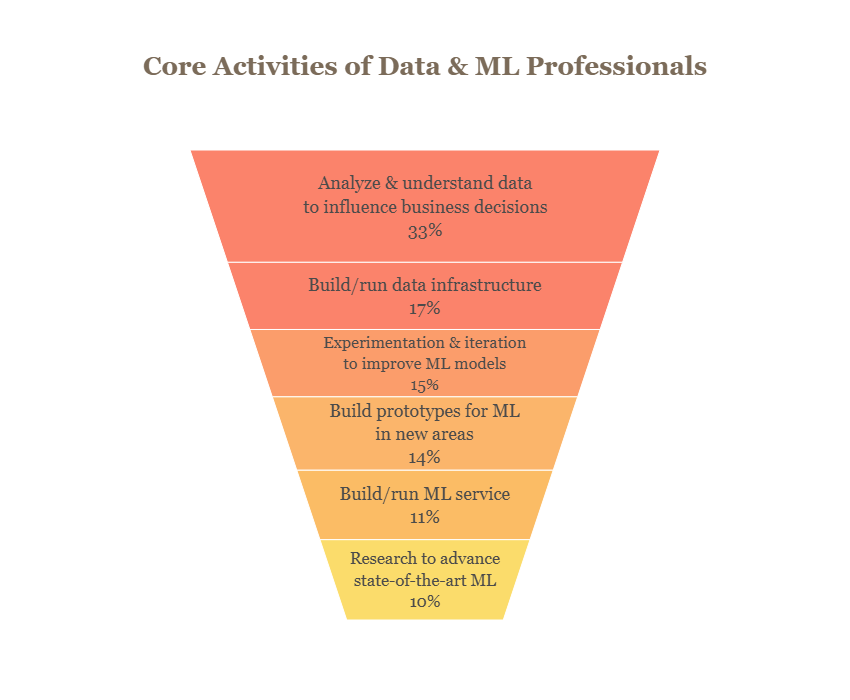

In [11]:
# =============================================================
# Funnel chart: Core Activities of Data & ML Professionals
# =============================================================
dfs_list = []

data_ml_roles = [
    "Data Analyst (Business, Marketing, Financial, Quantitative, etc)",
    "Data Scientist",
    "Machine Learning/ MLops Engineer",
    "Research Scientist",
    "Data Engineer"
]

ml_indonesia_df = indonesia_df[
    indonesia_df["Q23"].str.strip().isin(data_ml_roles)
]

q28_cols = [col for col in df.columns if col.startswith("Q28")]
for col in q28_cols:
    temp = ml_indonesia_df.groupby(col).agg(counts=("Q2", "count")).reset_index()
    temp.columns = ["ML Activities", "counts"]
    dfs_list.append(temp)

ml_activities = pd.concat(dfs_list)
ml_activities["relative_percent"] = ml_activities["counts"] / ml_activities["counts"].sum()
ml_activities = ml_activities.sort_values("relative_percent", ascending=False)
ml_activities = ml_activities[
    ~(ml_activities["ML Activities"].str.contains("None", na=False) |
      ml_activities["ML Activities"].str.contains("Other", na=False))
]

map_ml_activities = {
    "Analyze and understand data to influence product or business decisions":
        "Analyze & understand data<br>to influence business decisions",
    "Build prototypes to explore applying machine learning to new areas":
        "Build prototypes for ML<br>in new areas",
    "Build and/or run the data infrastructure that my business uses for storing, analyzing, and operationalizing data":
        "Build/run data infrastructure",
    "Experimentation and iteration to improve existing ML models":
        "Experimentation & iteration<br>to improve ML models",
    "Build and/or run a machine learning service that operationally improves my product or workflows":
        "Build/run ML service",
    "Do research that advances the state of the art of machine learning":
        "Research to advance<br>state-of-the-art ML"
}
ml_activities["ML Activities"] = ml_activities["ML Activities"].map(map_ml_activities).fillna(ml_activities["ML Activities"])

fig = go.Figure(go.Funnelarea(
    values=ml_activities["counts"].tolist(),
    text=ml_activities["ML Activities"].tolist(),
    marker={"colors": ["#fa4f2d", "#fa4f2d", "#fa752d", "#fa972d", "#faa125", "#face2d"]},
    textfont={"family": "Georgia", "size": 18, "color": "black"},
    opacity=0.70
))

fig.update_layout(
    title={
        "text": "<b><span style='font-size:26px; font-family:Georgia'>Core Activities of Data & ML Professionals</span></b>",
        "x": 0.5, "xanchor": "center"
    },
    font=dict(color='#7b6b59'),
    margin=dict(t=150),
    width=850, height=700,
    plot_bgcolor="white"
)
fig.update_traces(showlegend=False)
fig.show(renderer='png')


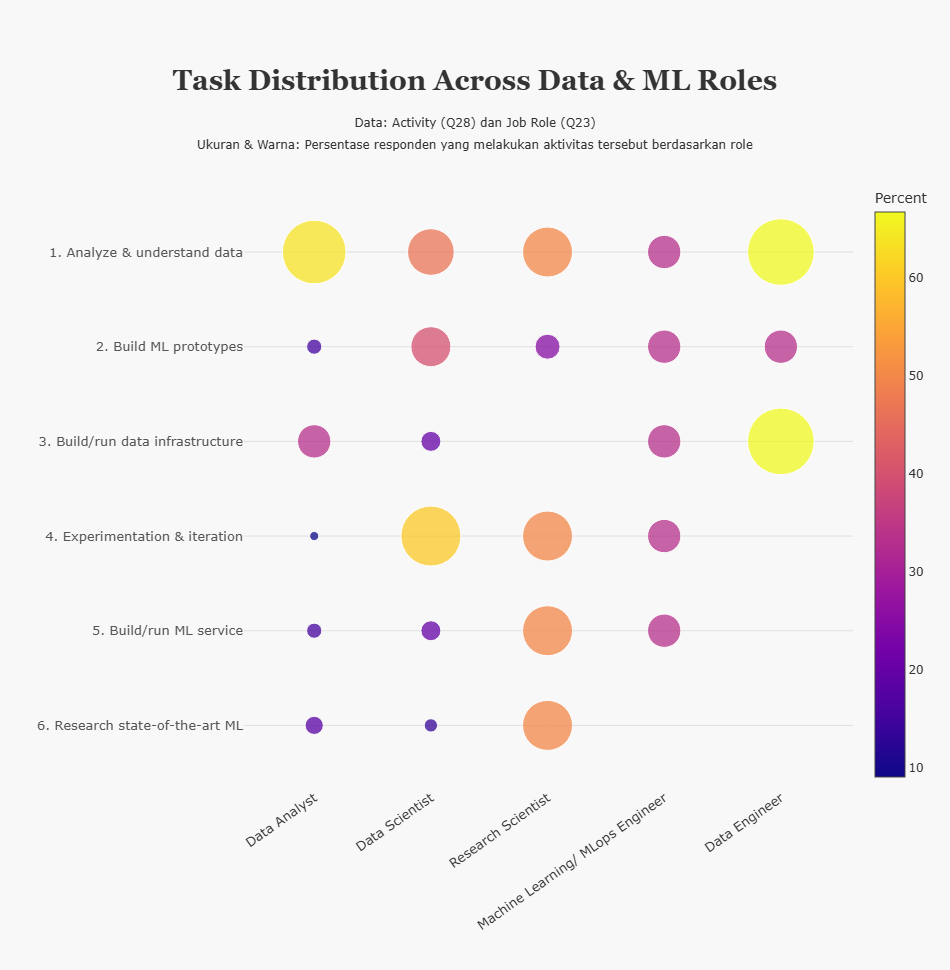

In [12]:
# ============================================================
# Scatter plot: Task Distribution Across Data & ML Roles
# ============================================================
jobs_in_scope = [
    "Data Analyst (Business, Marketing, Financial, Quantitative, etc)",
    "Data Scientist",
    "Machine Learning/ MLops Engineer",
    "Research Scientist",
    "Data Engineer"
]
activities = [col for col in df.columns if col.startswith("Q28")]
job_roles = indonesia_df["Q23"].str.strip().value_counts().to_dict()

dfs_list = []
for role in jobs_in_scope:
    for col in activities:
        temp = (
            indonesia_df[indonesia_df["Q23"].str.strip() == role]
            .groupby(["Q23", col])
            .agg(counts=("Q2", "count"))
            .reset_index()
        )
        temp.columns = ["Q23", "ML Activities", "counts"]
        dfs_list.append(temp)

results = pd.concat(dfs_list)
results["Q23"] = results["Q23"].str.strip()
results["relative_percent"] = results.apply(
    lambda x: x["counts"] / job_roles.get(x["Q23"], 1), axis=1
)
results = results[
    ~(results["ML Activities"].str.contains("None", na=False) |
      results["ML Activities"].str.contains("Other", na=False))
]

map_ml_activities2 = {
    "Analyze and understand data to influence product or business decisions":
        "1. Analyze & understand data",
    "Build prototypes to explore applying machine learning to new areas":
        "2. Build ML prototypes",
    "Build and/or run the data infrastructure that my business uses for storing, analyzing, and operationalizing data":
        "3. Build/run data infrastructure",
    "Experimentation and iteration to improve existing ML models":
        "4. Experimentation & iteration",
    "Build and/or run a machine learning service that operationally improves my product or workflows":
        "5. Build/run ML service",
    "Do research that advances the state of the art of machine learning":
        "6. Research state-of-the-art ML"
}
results["ML Activities"] = results["ML Activities"].map(map_ml_activities2).fillna(results["ML Activities"])
results = results.sort_values("ML Activities", ascending=False)

create_scatter_plot(
    x_axis_values=results["Q23"].apply(lambda x: x.split("(")[0].strip()),
    y_axis_values=results["ML Activities"],
    hover_template=(
        "Role: %{x}<br>"
        "ML Activity: %{y}<br>"
        "Percentage: %{customdata:.1f}%" 
        "<extra></extra>"
    ),
    marker_color=results["relative_percent"] * 100,
    marker_size=results["relative_percent"] * 100,
    customdata=results["relative_percent"] * 100, 
    title="Task Distribution Across Data & ML Roles",
    subtitle="Data: Activity (Q28) dan Job Role (Q23)",
    subtitle_explain=(
        "Ukuran & Warna: Persentase responden yang melakukan aktivitas tersebut berdasarkan role"
    )
)

### 5.5 ❓ Q3: Gender Distribution of Data & Tech Jobs in Indonesia


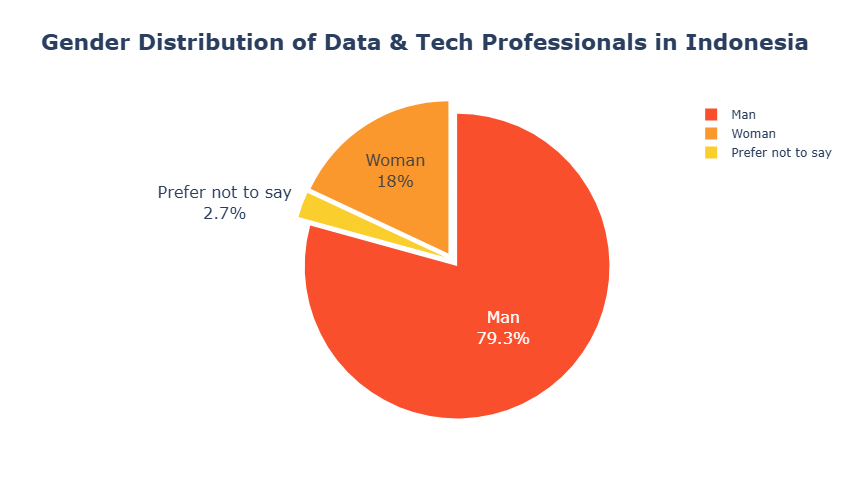

In [13]:
# ============================================================
# Pie chart: Distribusi Gender
# ============================================================
gender_df = (
    indonesia_df.groupby("Q3")
    .agg(counts=("Q2", "count"))
    .reset_index()
)
gender_df["relative_percent"] = gender_df["counts"] / indonesia_df.shape[0]
gender_df = gender_df[~gender_df["Q3"].isin(["None", "Other"])].sort_values("relative_percent")

fig = px.pie(
    gender_df,
    values="relative_percent",
    names="Q3",
    title="<b>Gender Distribution of Data & Tech Professionals in Indonesia</b>",
    hover_data=["counts"],
    labels={"relative_percent": "Percentage", "Q3": "Gender"},
    color_discrete_sequence=["#fa4f2d", "#fa972d", "#face2d"]
)
fig.update_traces(
    textinfo="percent+label",
    pull=[0.05] * len(gender_df),
    textfont_size=16
)
fig.update_layout(
    title_font_size=22,
    title_x=0.5,
    width=850, height=500
)
fig.show(renderer='png')


### 5.6 ❓ Q4: Educational Qualifications of Data & Tech Professionals in Indonesia


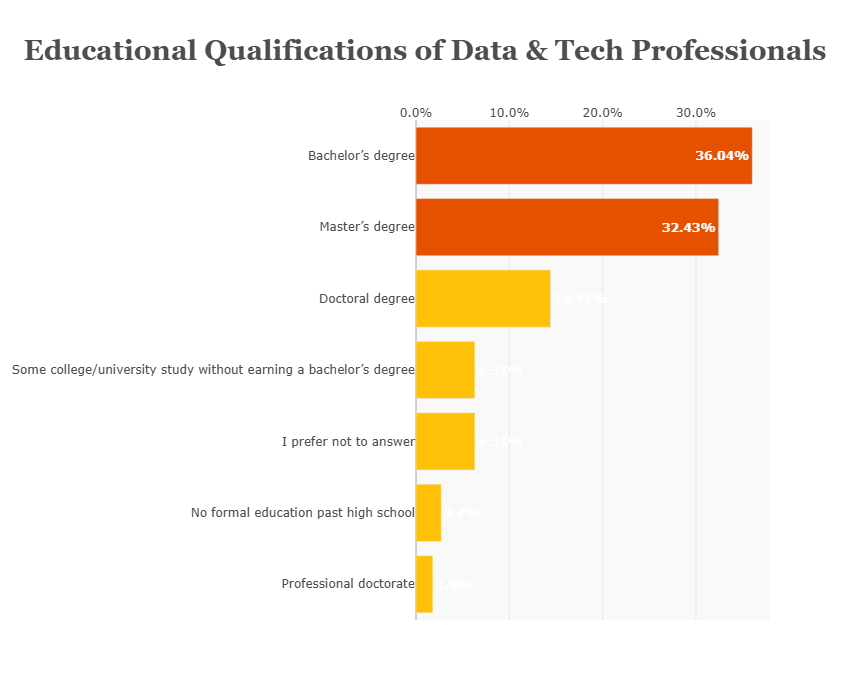

In [14]:
# ============================================================
# Bar chart: Tingkat Pendidikan
# ============================================================
education_df = (
    indonesia_df.groupby("Q8")
    .agg(counts=("Q2", "count"))
    .reset_index()
    .rename(columns={"Q8": "education_level"})
)
education_df["relative_percent"] = education_df["counts"] / indonesia_df.shape[0]
education_df = education_df.sort_values("relative_percent", ascending=True)

create_single_bar_plot(
    x_values=education_df["relative_percent"].tolist(),
    y_values=education_df["education_level"].tolist(),
    display_text=np.round(education_df["relative_percent"] * 100, decimals=2),
    top_n=2,
    rest_n=len(education_df) - 2,
    hovertext=education_df["counts"].tolist(),
    title="Educational Qualifications of Data & Tech Professionals",
    orientation="h"
)


## 6. Kesimpulan

| # | Pertanyaan Penelitian | Temuan Utama |
|---|-----------|-------------|
| 1 | **Top Job Positions** | Data Scientist dan Data Analyst adalah dua posisi teratas yang paling banyak diisi oleh profesional Data & Tech di Indonesia. Aktivitas utama yang dilakukan meliputi analisis data untuk pengambilan keputusan bisnis serta pembangunan infrastruktur data. |
| 2 | **Industri** | Sektor Academics/Education menjadi industri terbesar yang menyerap profesional Data & Tech (35 responden), diikuti Computers/Technology (19) dan Accounting/Finance (11). Hal ini menunjukkan bahwa permintaan talenta data tidak hanya berasal dari industri teknologi, tetapi juga dari pendidikan dan keuangan. |
| 3 | **Gender** | Terdapat kesenjangan gender yang signifikan di industri Data & Tech Indonesia, dengan dominasi responden laki-laki. Kondisi ini mencerminkan perlunya upaya lebih besar dalam mendorong inklusivitas gender di bidang teknologi dan sains data di Indonesia. |
| 4 | **Pendidikan** | Mayoritas profesional Data & Tech di Indonesia memiliki gelar Sarjana (S1) sebagai pendidikan minimum. Gelar Magister (S2) juga cukup umum, terutama di kalangan Research Scientist dan peran manajerial. |

Secara keseluruhan, ekosistem Data & Tech di Indonesia pada 2022 menunjukkan pertumbuhan yang menjanjikan dengan permintaan tinggi di berbagai sektor. Namun, masih diperlukan peningkatan keberagaman gender serta perluasan jalur pendidikan formal dan non-formal untuk memenuhi kebutuhan talenta yang terus berkembang.

*Analisis ini menggunakan data Kaggle Survey 2022 dengan fokus pada 111 responden profesional Data & Tech di Indonesia dari total 23.997 responden global (tidak sedang bersekolah dan aktif bekerja).*
